#  FC +8T — Temperature Dependence
**Device:** FGT-OFGT-CrPS4

**Data folder:** `data/Device2/Plots_done_on_20230425/Field_cooling_8T`  
**Measurement:** Field-cooled at +8T from room temperature; hysteresis loops at each T.  


In [3]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import sys
sys.path.insert(0, str(Path().resolve().parent))
from scripts.data_loader import (
    load_h5, load_txt, get_file_list,
    offset_and_AHE, normalize,
    coercivity_zero_crossing, coercivity_largest_jump,
    exchange_bias, coercive_width,
    sort_serial, fixjump,
)
from scripts.notebook_setup import setup
setup()

PROJECT_ROOT = Path().resolve().parent
D2 = PROJECT_ROOT / 'data' / 'Device2'

[OK] Autoreload enabled
[OK] Project root (installed package): C:\Users\sadit\OneDrive - JGU\Projects\EB in FGT-OFGT_CrPS4
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!


In [11]:
FOLDER_FC8T = D2 / 'Plots_done_on_20230425' / 'Field_cooling_8T'

T_g, H1_g, H2_g = [], [], []
Field_g, Vxy_g, Vxy_err_g, Vxx_g, Vxx_err_g = [], [], [], [], []
Vxy_norm_g = []
Vahe_g, Vahe_err_g = [], []
R_g, HEB_err_g = [], []

def index_of(temperature):
    """Return list index of the given temperature in T_g."""
    for i, t in enumerate(T_g):
        if t == temperature:
            return i
    return None

for fp in get_file_list(FOLDER_FC8T):
    if fp.suffix.lower() == '.h5':
        d = load_h5(fp, channel_xy=2, P=3)
        F    = d['Field']
        Sig  = d['Vxy'].copy()
        ref  = d['Vxx']
        Serr = d['Vxy_err']
        Rerr = d['Vxx_err']
        T    = d['T']
        if T == 30:
            Sig = fixjump(Sig, 0.2, guessindex=50)
    else:  # .txt — Device2 12T format: V2=Hall, skiprows=15
        d = load_txt(fp, skiprows=15, vxy_col='Voltage-2 (V)', trim='head')
        F    = d['Field']
        Sig  = d['Vxy']
        ref  = d['Vxx']
        Serr = d['Vxy_err']
        Rerr = d['Vxx_err']
        T    = d['T']

    offset, offset_err, Vahe, Vahe_err = offset_and_AHE(Sig)
    Sig_norm = normalize(Sig, offset, Vahe)
    HC_neg, HC_pos = coercivity_zero_crossing(F, Sig_norm)
    HEB  = exchange_bias(HC_neg, HC_pos)
    HC   = coercive_width(HC_neg, HC_pos)

    T_g.append(T);       H1_g.append(HC_neg);  H2_g.append(HC_pos)
    Field_g.append(F);   Vxy_g.append(Sig);     Vxy_err_g.append(Serr)
    Vxx_g.append(ref);   Vxx_err_g.append(Rerr)
    Vxy_norm_g.append(Sig_norm)
    Vahe_g.append(float(Vahe)); Vahe_err_g.append(float(Vahe_err))
    HEB_err_g.append((F[0] - F[1]) / 2)
    peak = np.max(ref);  idx = np.abs(ref - peak) < 0.5
    R_g.append(np.mean(ref[idx]) if idx.any() else peak)
    """
    # ── F1 per file: Vxy vs B ─────────────────────────────────────────────────
    plt.figure()
    plt.xlabel('Magnetic Field (mT)')
    plt.ylabel('Vxy (uV)')
    plt.title(f'Temperature: {T} K  EB: {int(HEB)} mT')
    plt.plot(F, Sig)
    plt.errorbar(F, Sig, Serr, fmt='o')
    plt.tight_layout()
    plt.show()

    # ── F2 per file: Vxx vs B ─────────────────────────────────────────────────
    plt.figure()
    plt.xlabel('Magnetic Field (mT)')
    plt.ylabel('Vxx (uV)')
    plt.title(f'Temperature: {T} K  EB: {int(HEB)} mT')
    plt.plot(F, ref)
    plt.errorbar(F, ref, Rerr, fmt='o')
    plt.tight_layout()
    plt.show()
    """

T_g      = np.array(T_g)
H1_g     = np.array(H1_g)
H2_g     = np.array(H2_g)
Vahe_g   = np.array(Vahe_g).flatten()
Vahe_err_g = np.array(Vahe_err_g).flatten()
R_g      = np.array(R_g)

W      = np.abs(H1_g - H2_g) / 2
HEB_g  = (H1_g + H2_g) / 2

sorted_T_g   = np.sort(T_g)
sorted_HEB_g = sort_serial(list(T_g), list(HEB_g))
sorted_W     = sort_serial(list(T_g), list(W))

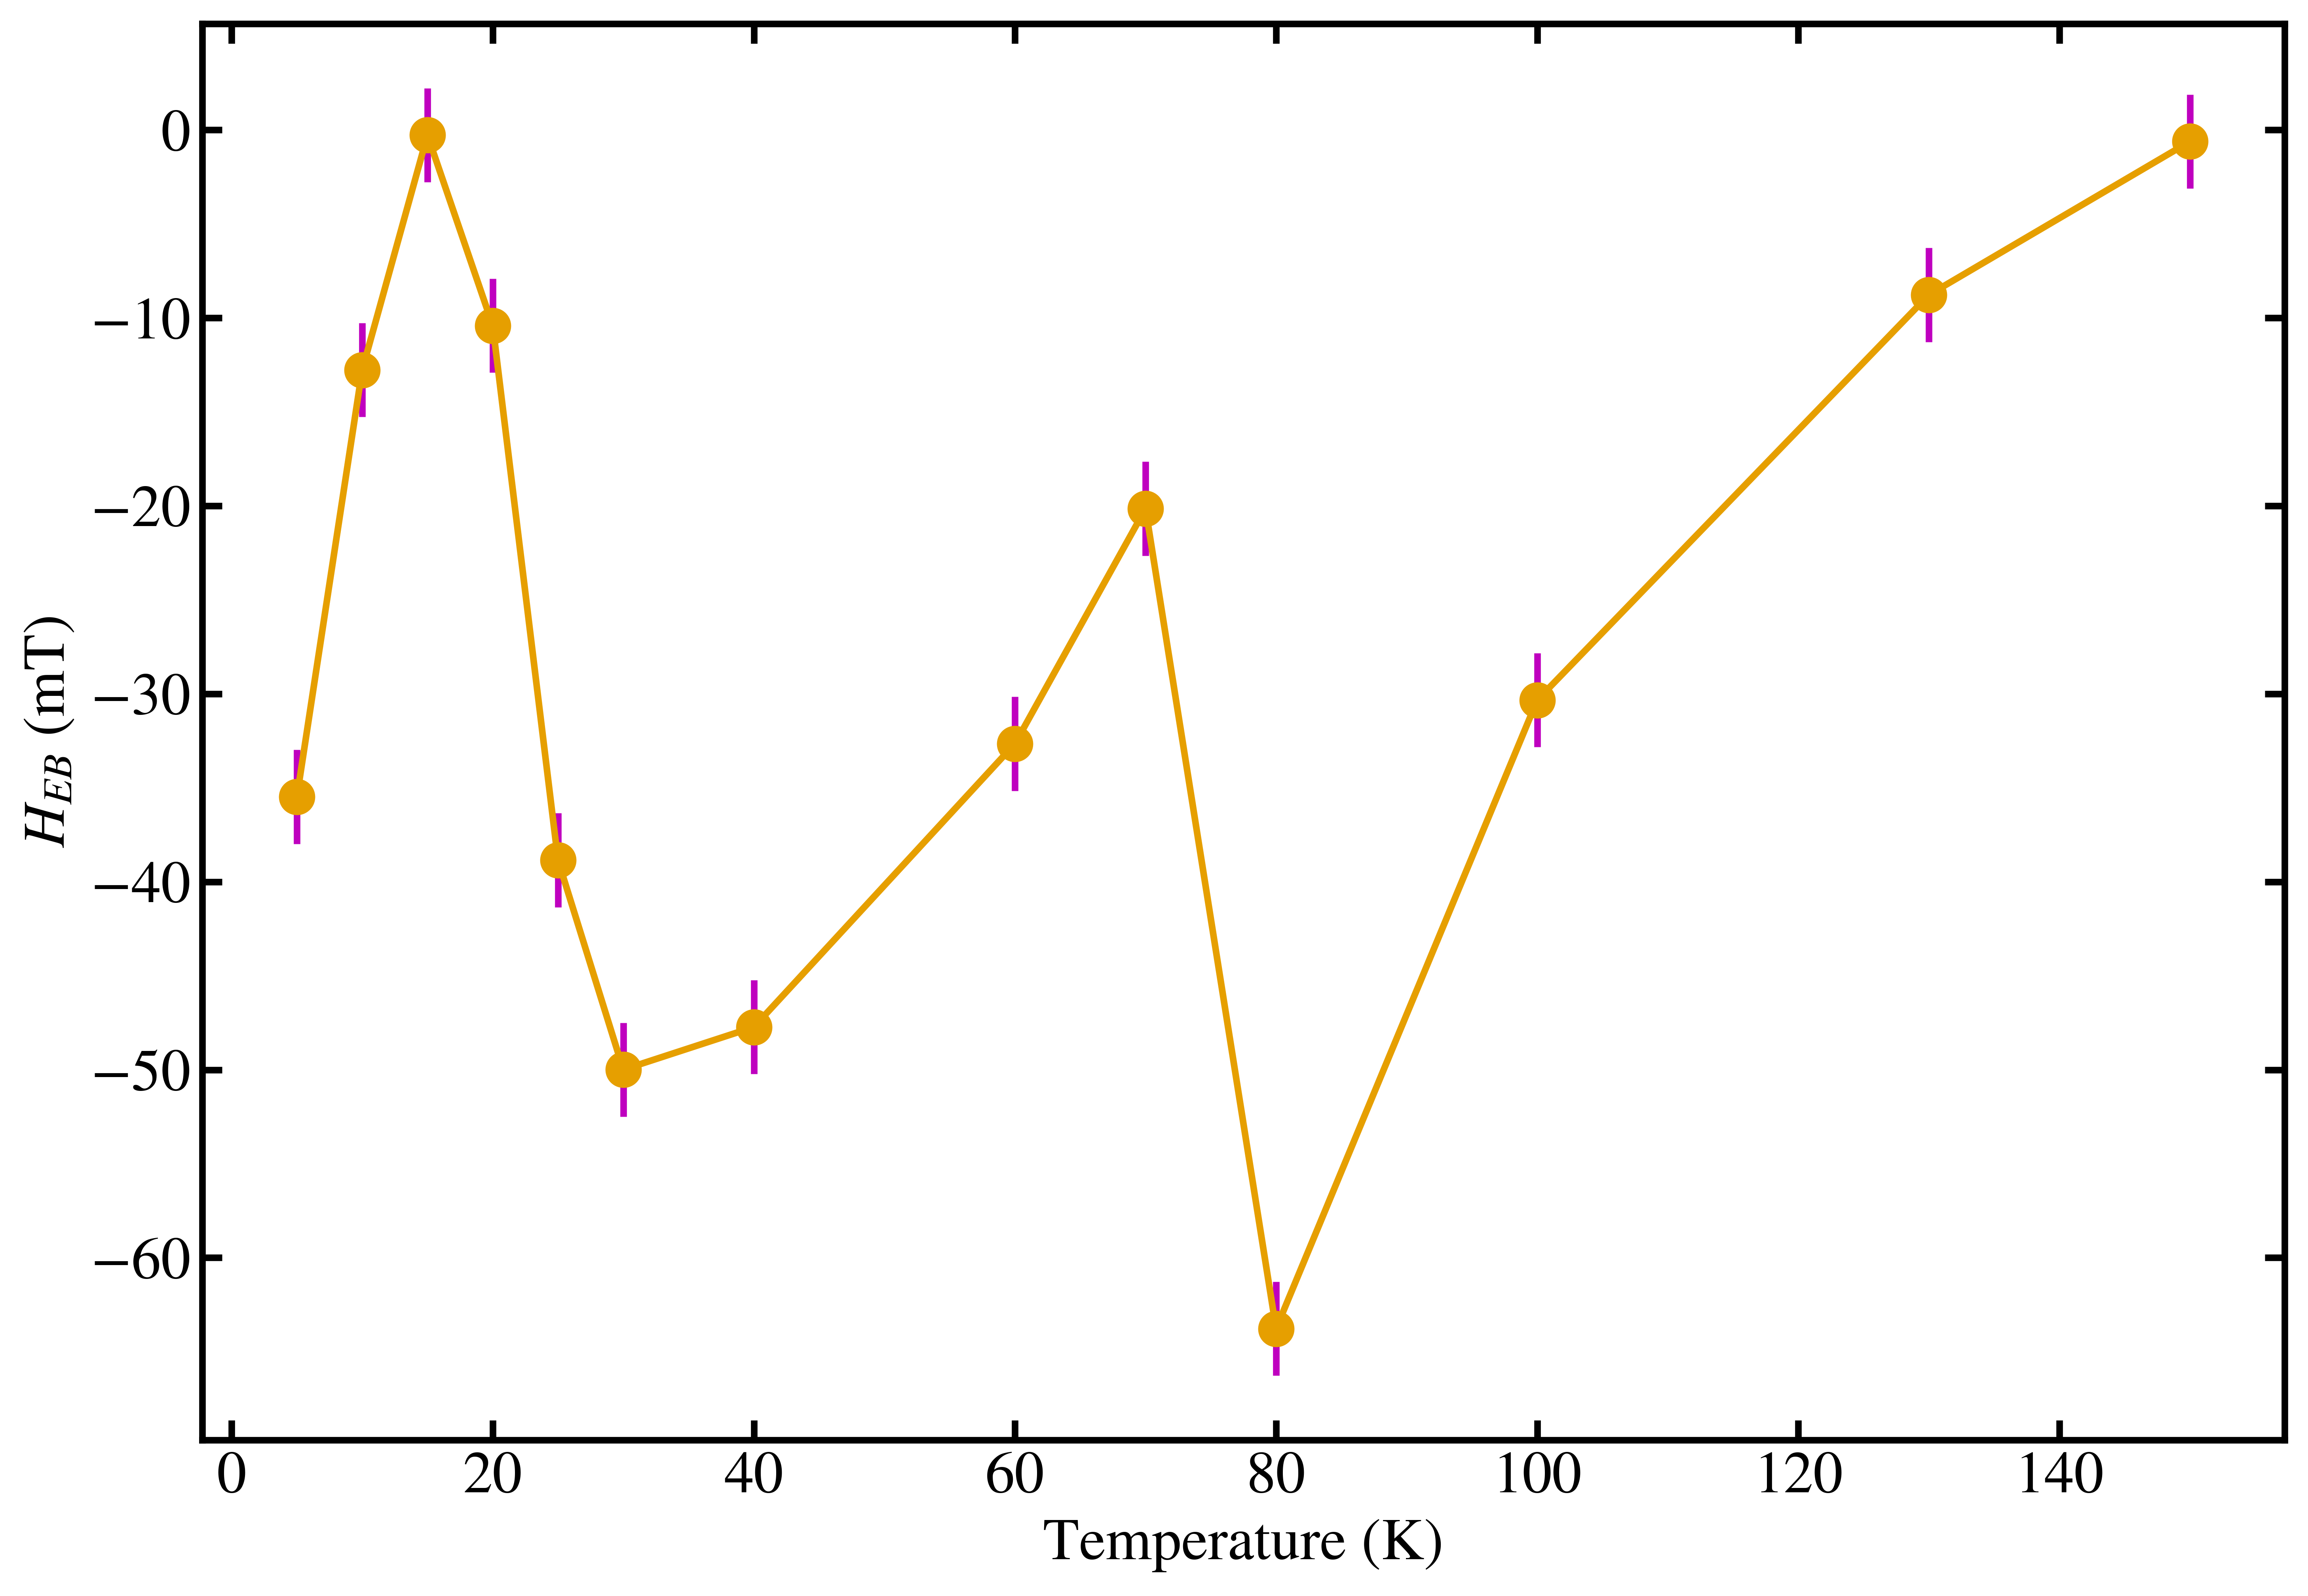

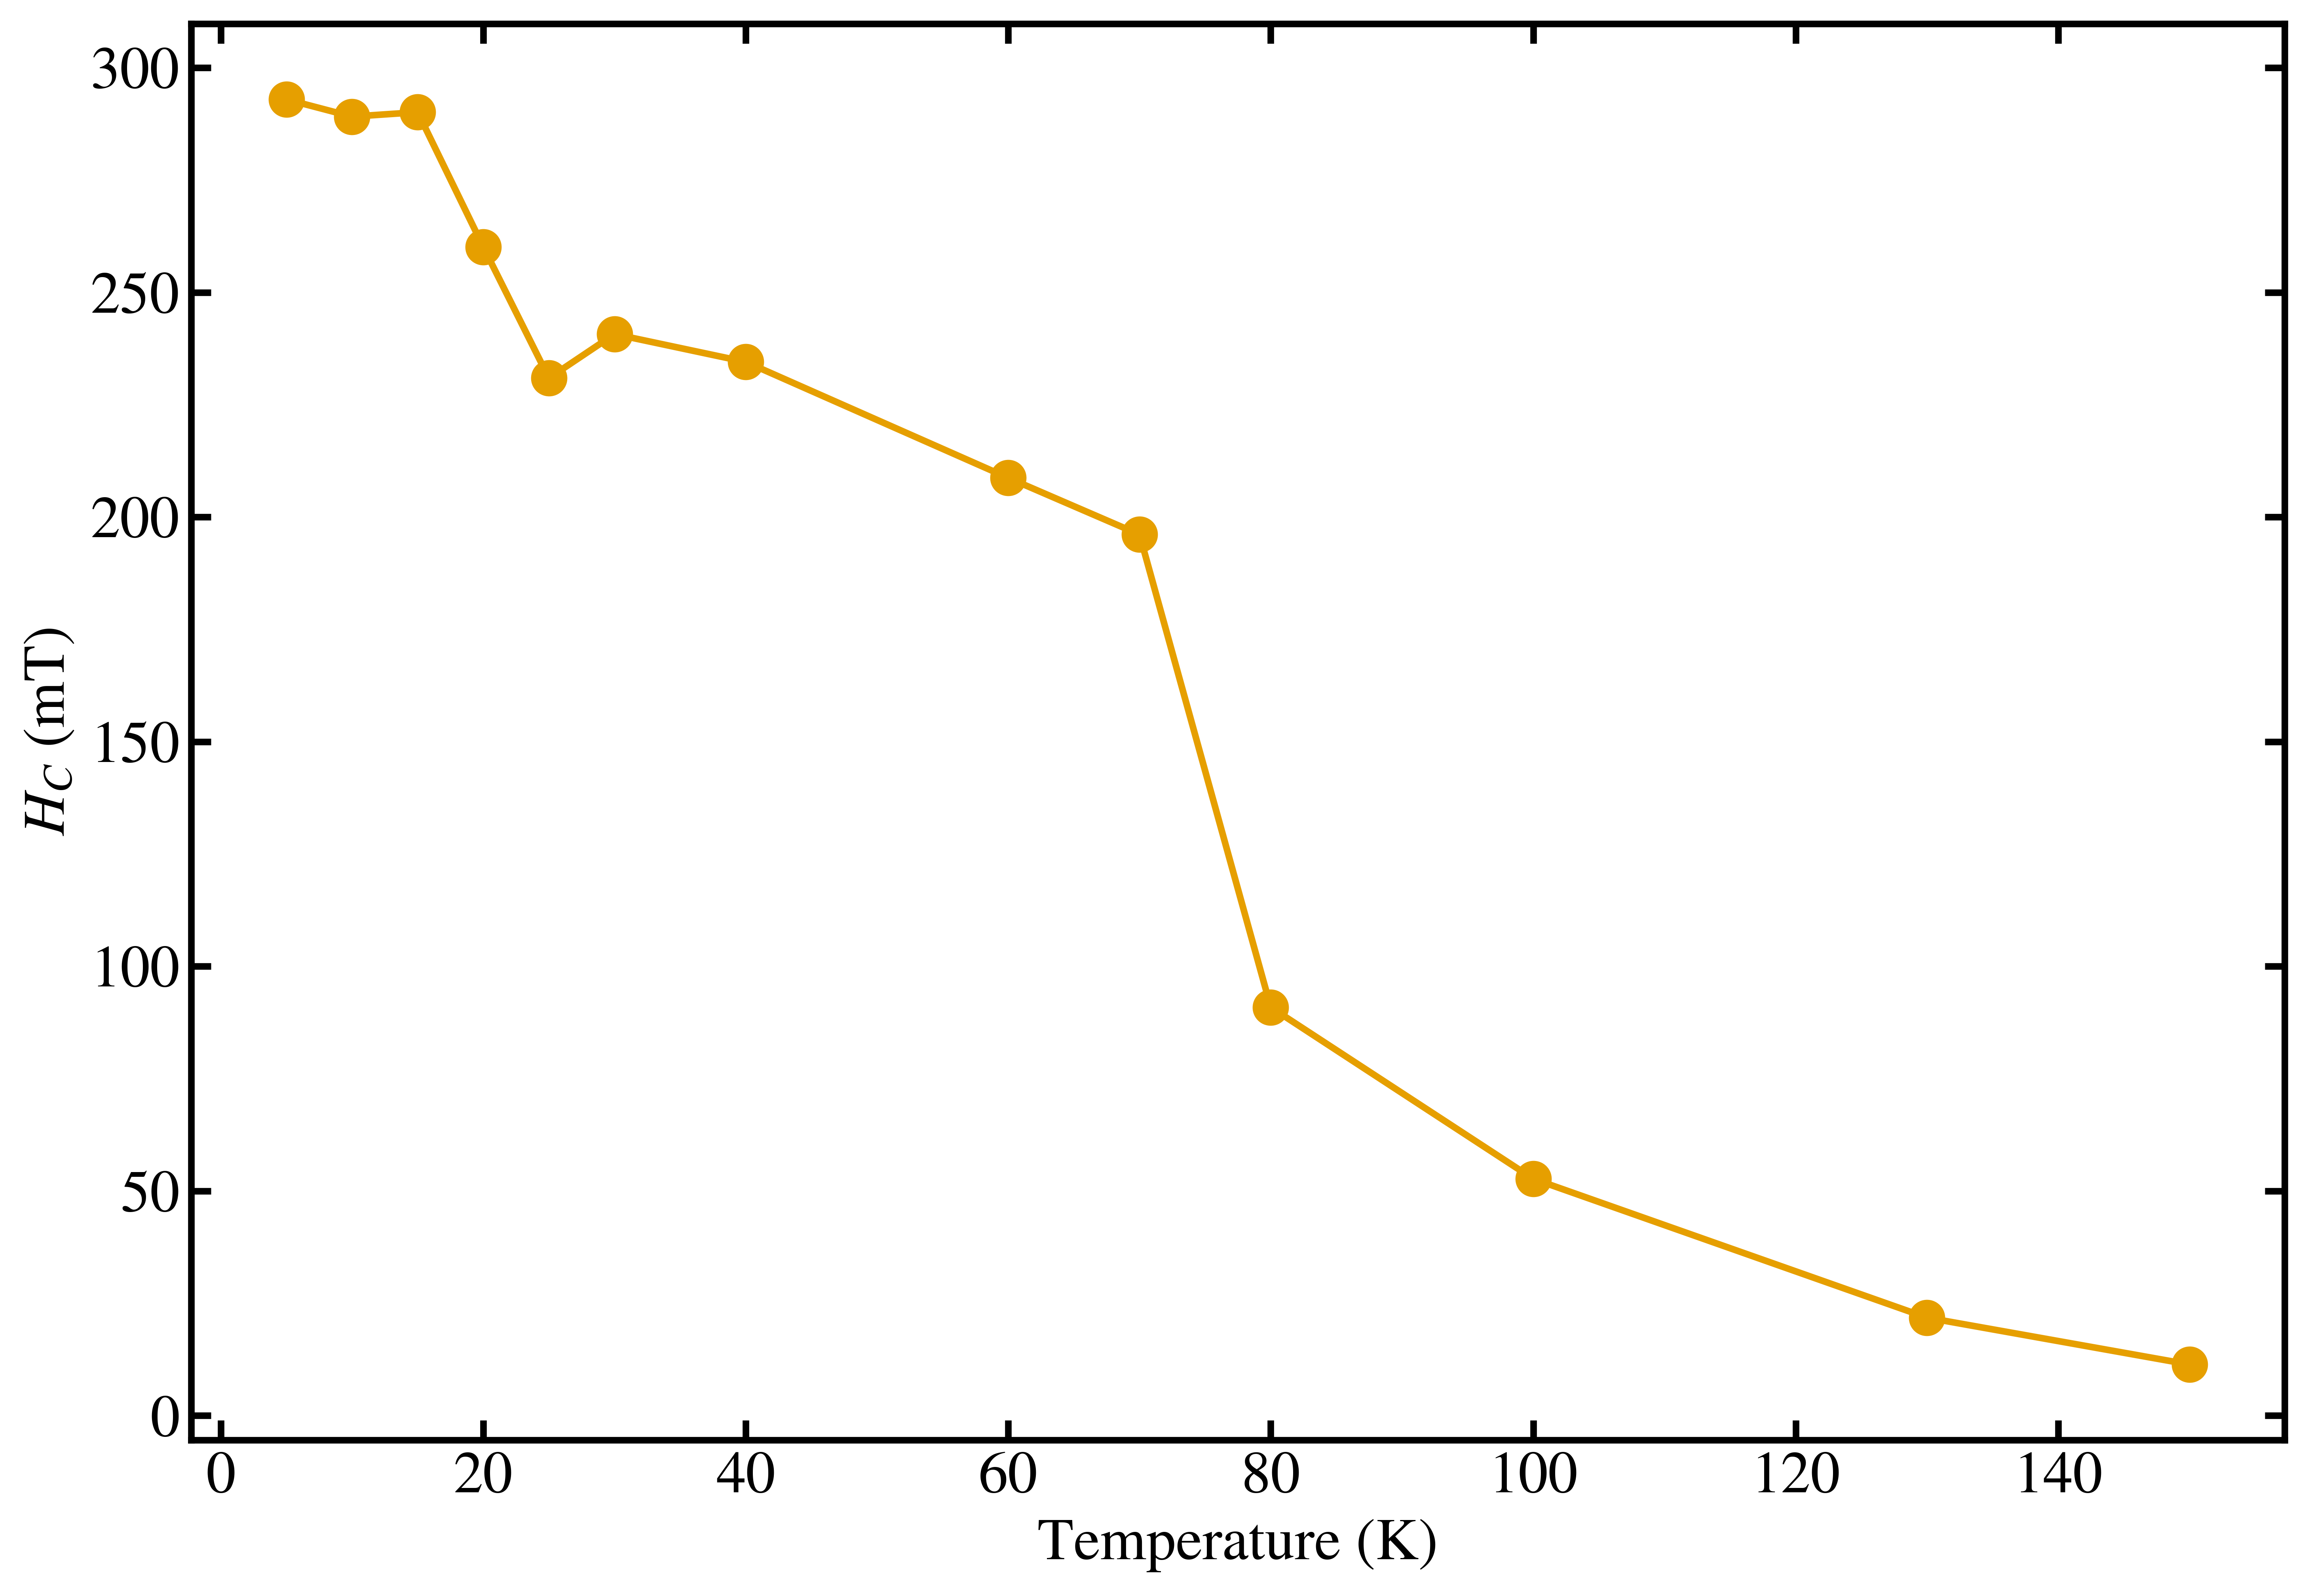

In [12]:
# ── F3: H_EB vs T ─────────────────────────────────────────────────────────────
plt.figure(dpi=600)
plt.errorbar(sorted_T_g, sorted_HEB_g, 2.5, fmt='-o', ecolor='m', markersize=10)
plt.xlabel('Temperature (K)', fontsize=18)
plt.ylabel('$H_{EB}$ (mT)', fontsize=18)
plt.tight_layout()
plt.show()

# ── F4: H_C vs T ──────────────────────────────────────────────────────────────
plt.figure(dpi=600)
plt.errorbar(sorted_T_g, sorted_W, 2.5, fmt='-o', ecolor='m', markersize=10)
plt.xlabel('Temperature (K)', fontsize=18)
plt.ylabel('$H_C$ (mT)', fontsize=18)
plt.tight_layout()
plt.show()

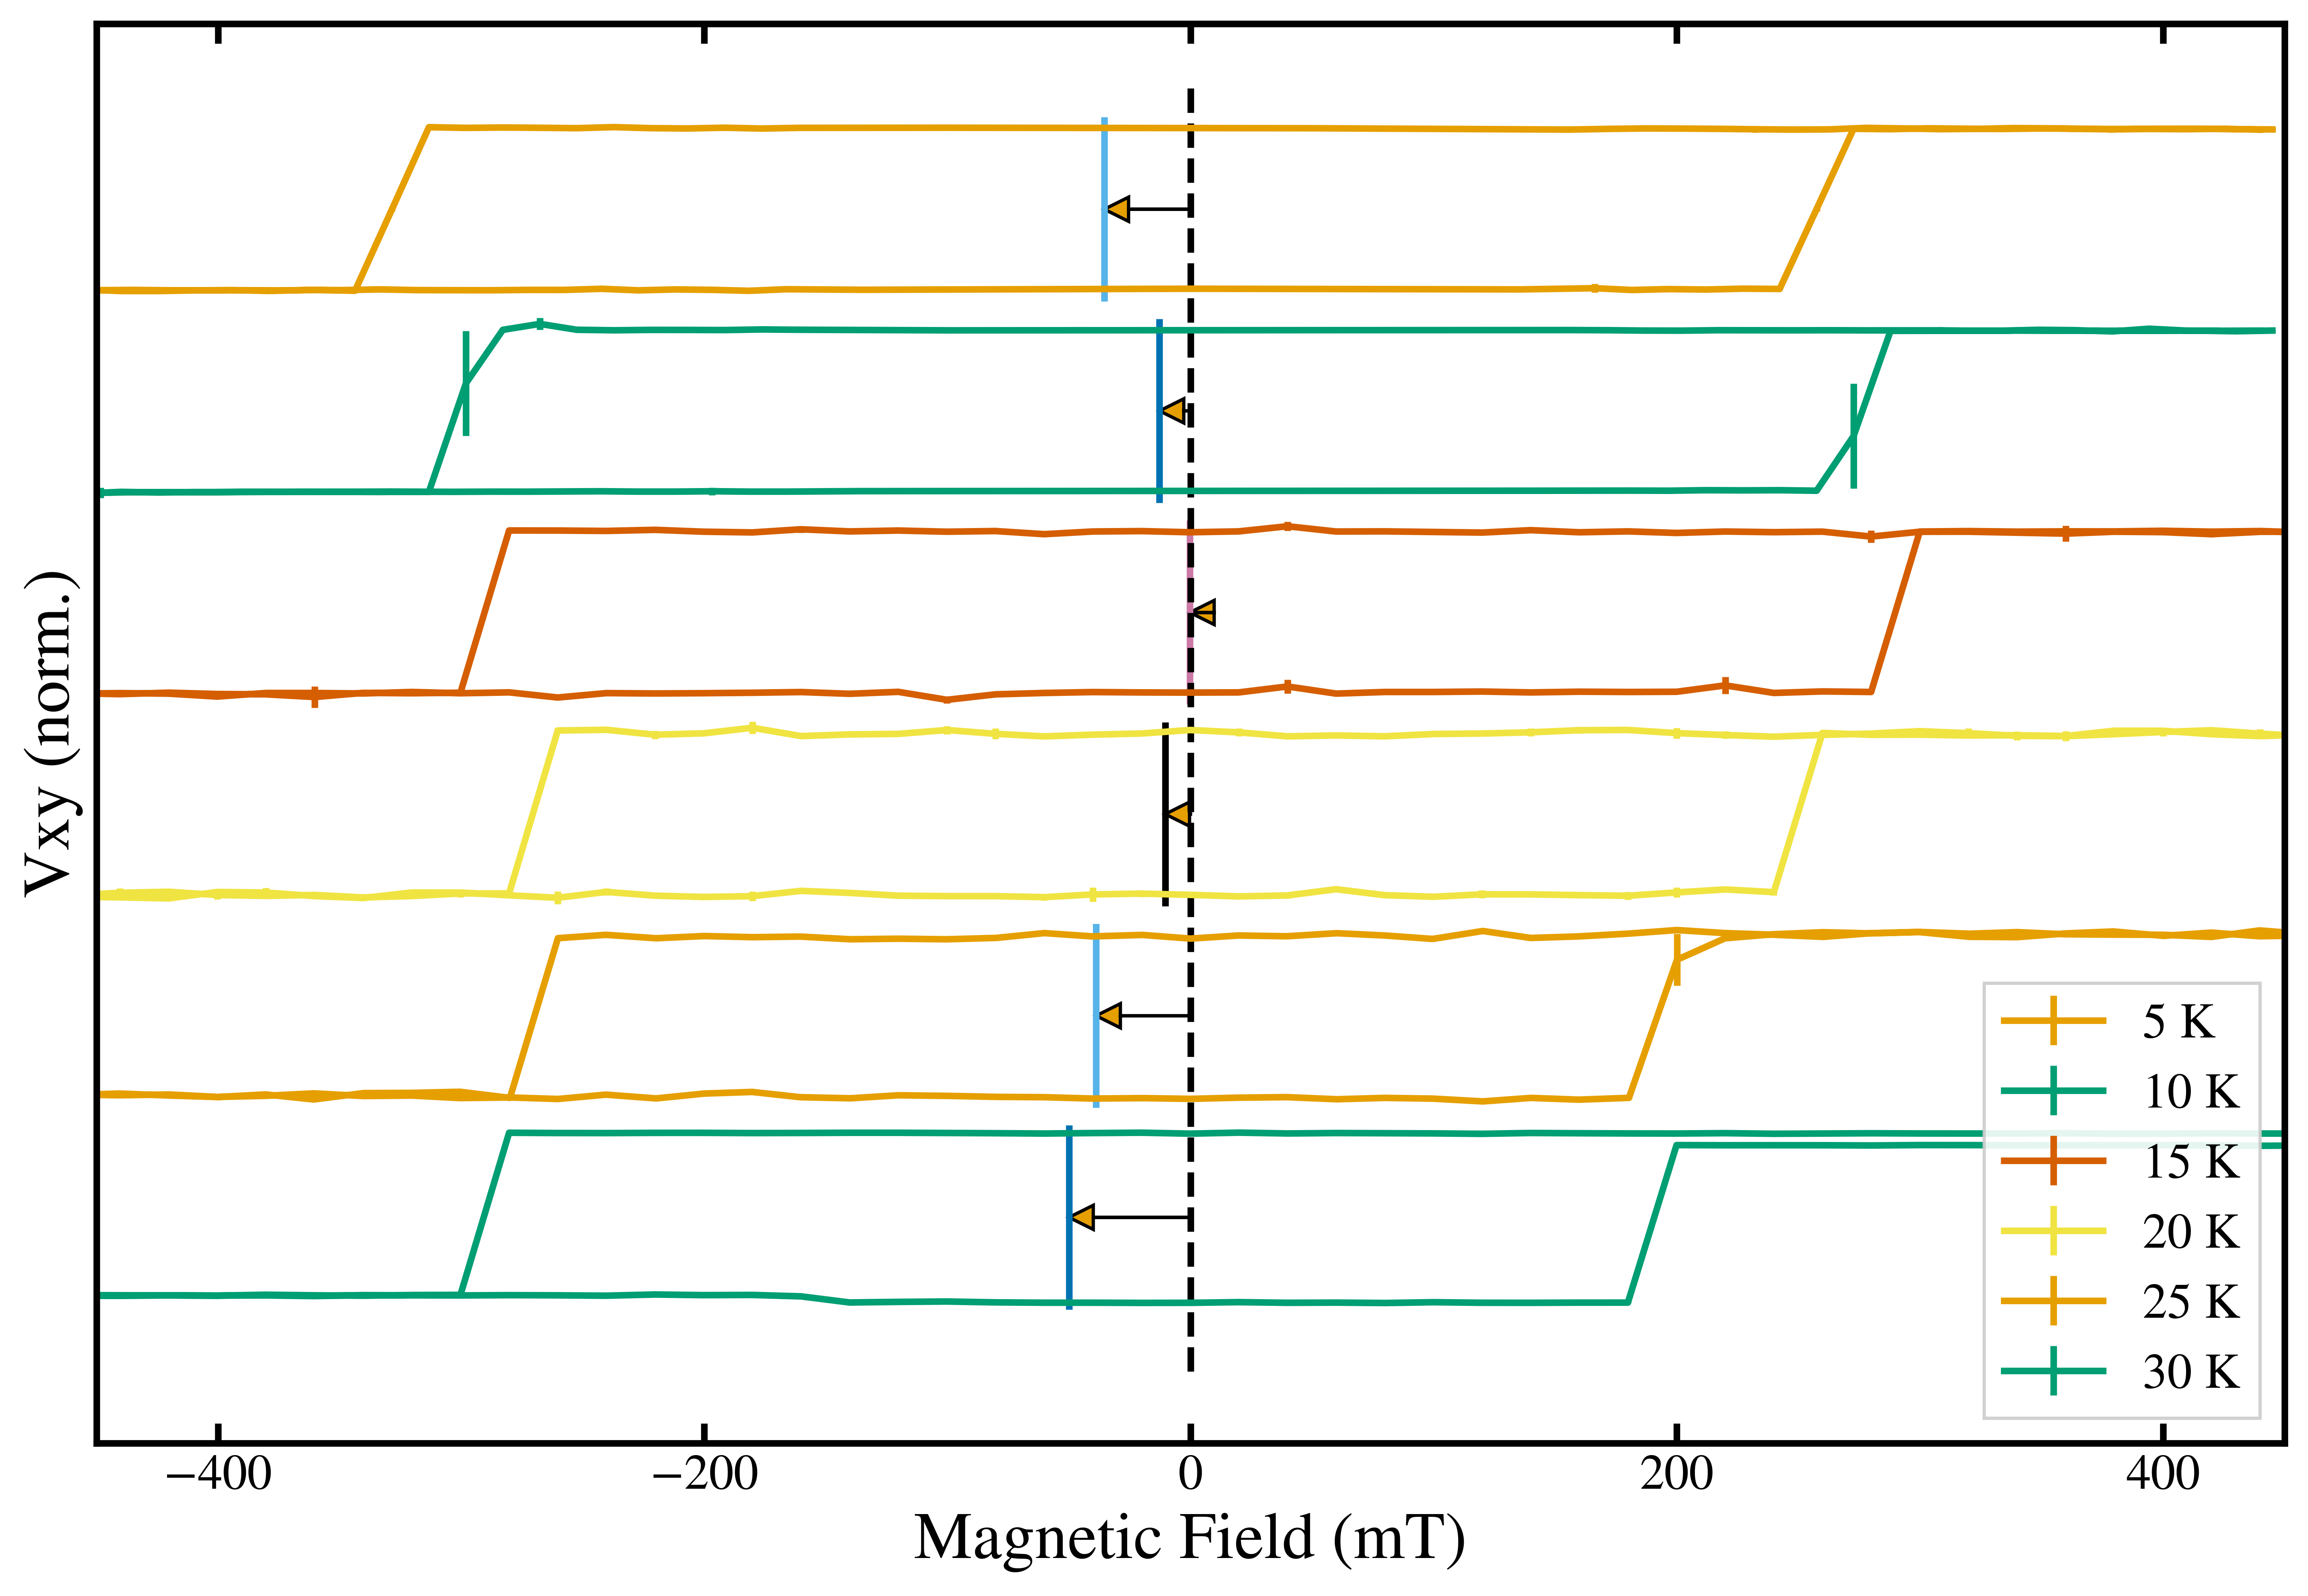

In [13]:
# ── F5: Waterfall 5–30 K ──────────────────────────────────────────────────────
# offsets: 20.5, 18, 15.5, 13, 10.5, 8  |  sign flip at 25 K
temps5  = [5, 10, 15, 20, 25, 30]
offsets5 = [20.5, 18, 15.5, 13, 10.5, 8]
flip5    = {25}  # temperatures whose signal is sign-flipped

plt.figure(dpi=600)
for T_val, off in zip(temps5, offsets5):
    i = index_of(T_val)
    if i is None:
        print(f'[WARNING] T={T_val} K not found')
        continue
    sig = (-1 * Vxy_norm_g[i]) if T_val in flip5 else Vxy_norm_g[i]
    plt.errorbar(Field_g[i], sig + off, Vxy_err_g[i], fmt='-', markersize=1, label=f'{T_val} K')
    plt.plot([HEB_g[i], HEB_g[i]], [off + 1.1, off + 1.1 - 2.2], '-')
    plt.arrow(0, off, HEB_g[i], 0, head_width=0.3, head_length=10, length_includes_head=True)

plt.legend( loc='lower right', fontsize=15)
plt.plot([0, 0], [22, 6], '--', color='k')
plt.xlabel('Magnetic Field (mT)', fontsize=20)
plt.ylabel('Vxy (norm.)', fontsize=20)
plt.xticks([-400, -200, 0, 200, 400], fontsize=15)
plt.yticks([])
plt.xlim(-450, 450)
plt.tight_layout()
plt.show()

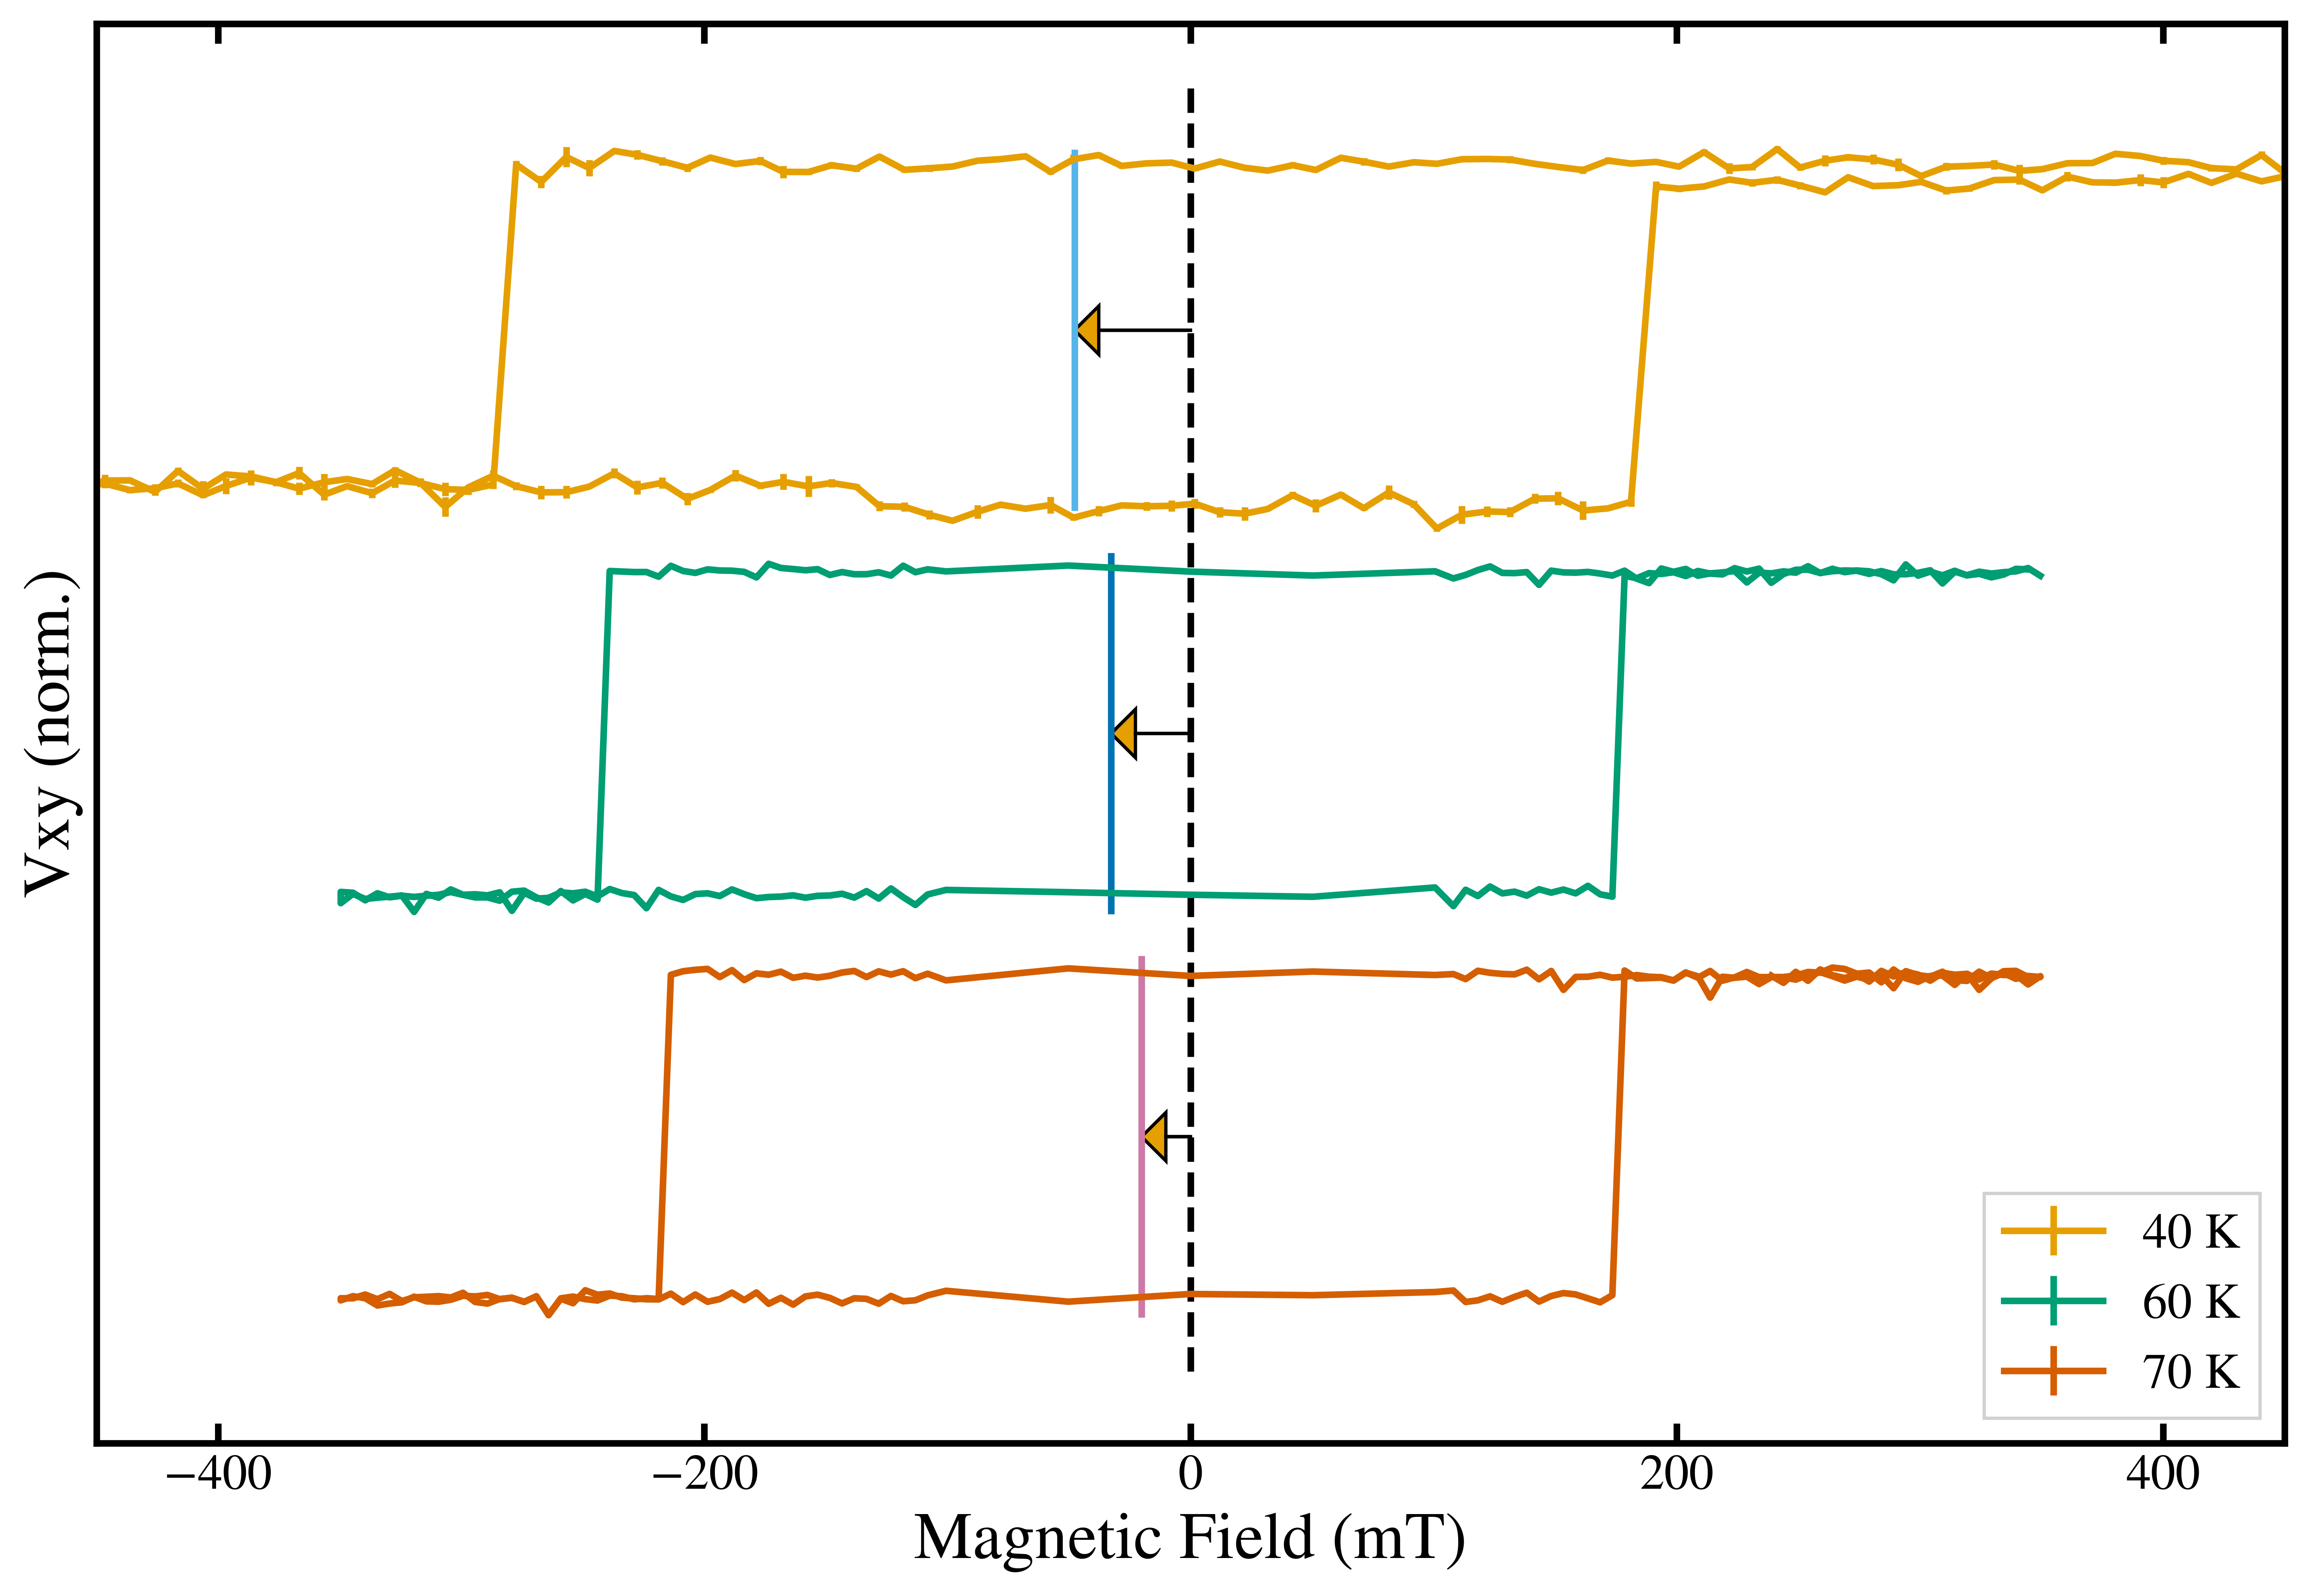

In [14]:
# ── F6: Waterfall 40–70 K ─────────────────────────────────────────────────────
# sign flip at 40 K
temps6   = [40, 60, 70]
offsets6 = [20.5, 18, 15.5]
flip6    = {40}

plt.figure(dpi=600)
for T_val, off in zip(temps6, offsets6):
    i = index_of(T_val)
    if i is None:
        print(f'[WARNING] T={T_val} K not found')
        continue
    sig = (-1 * Vxy_norm_g[i]) if T_val in flip6 else Vxy_norm_g[i]
    plt.errorbar(Field_g[i], sig + off, Vxy_err_g[i], fmt='-', markersize=1, label=f'{T_val} K')
    plt.plot([HEB_g[i], HEB_g[i]], [off + 1.1, off + 1.1 - 2.2], '-')
    plt.arrow(0, off, HEB_g[i], 0, head_width=0.3, head_length=10, length_includes_head=True)

plt.legend( loc='lower right', fontsize=15)
plt.plot([0, 0], [22, 14], '--', color='k')
plt.xlabel('Magnetic Field (mT)', fontsize=20)
plt.ylabel('Vxy (norm.)', fontsize=20)
plt.xticks([-400, -200, 0, 200, 400], fontsize=15)
plt.yticks([])
plt.xlim(-450, 450)
plt.tight_layout()
plt.show()

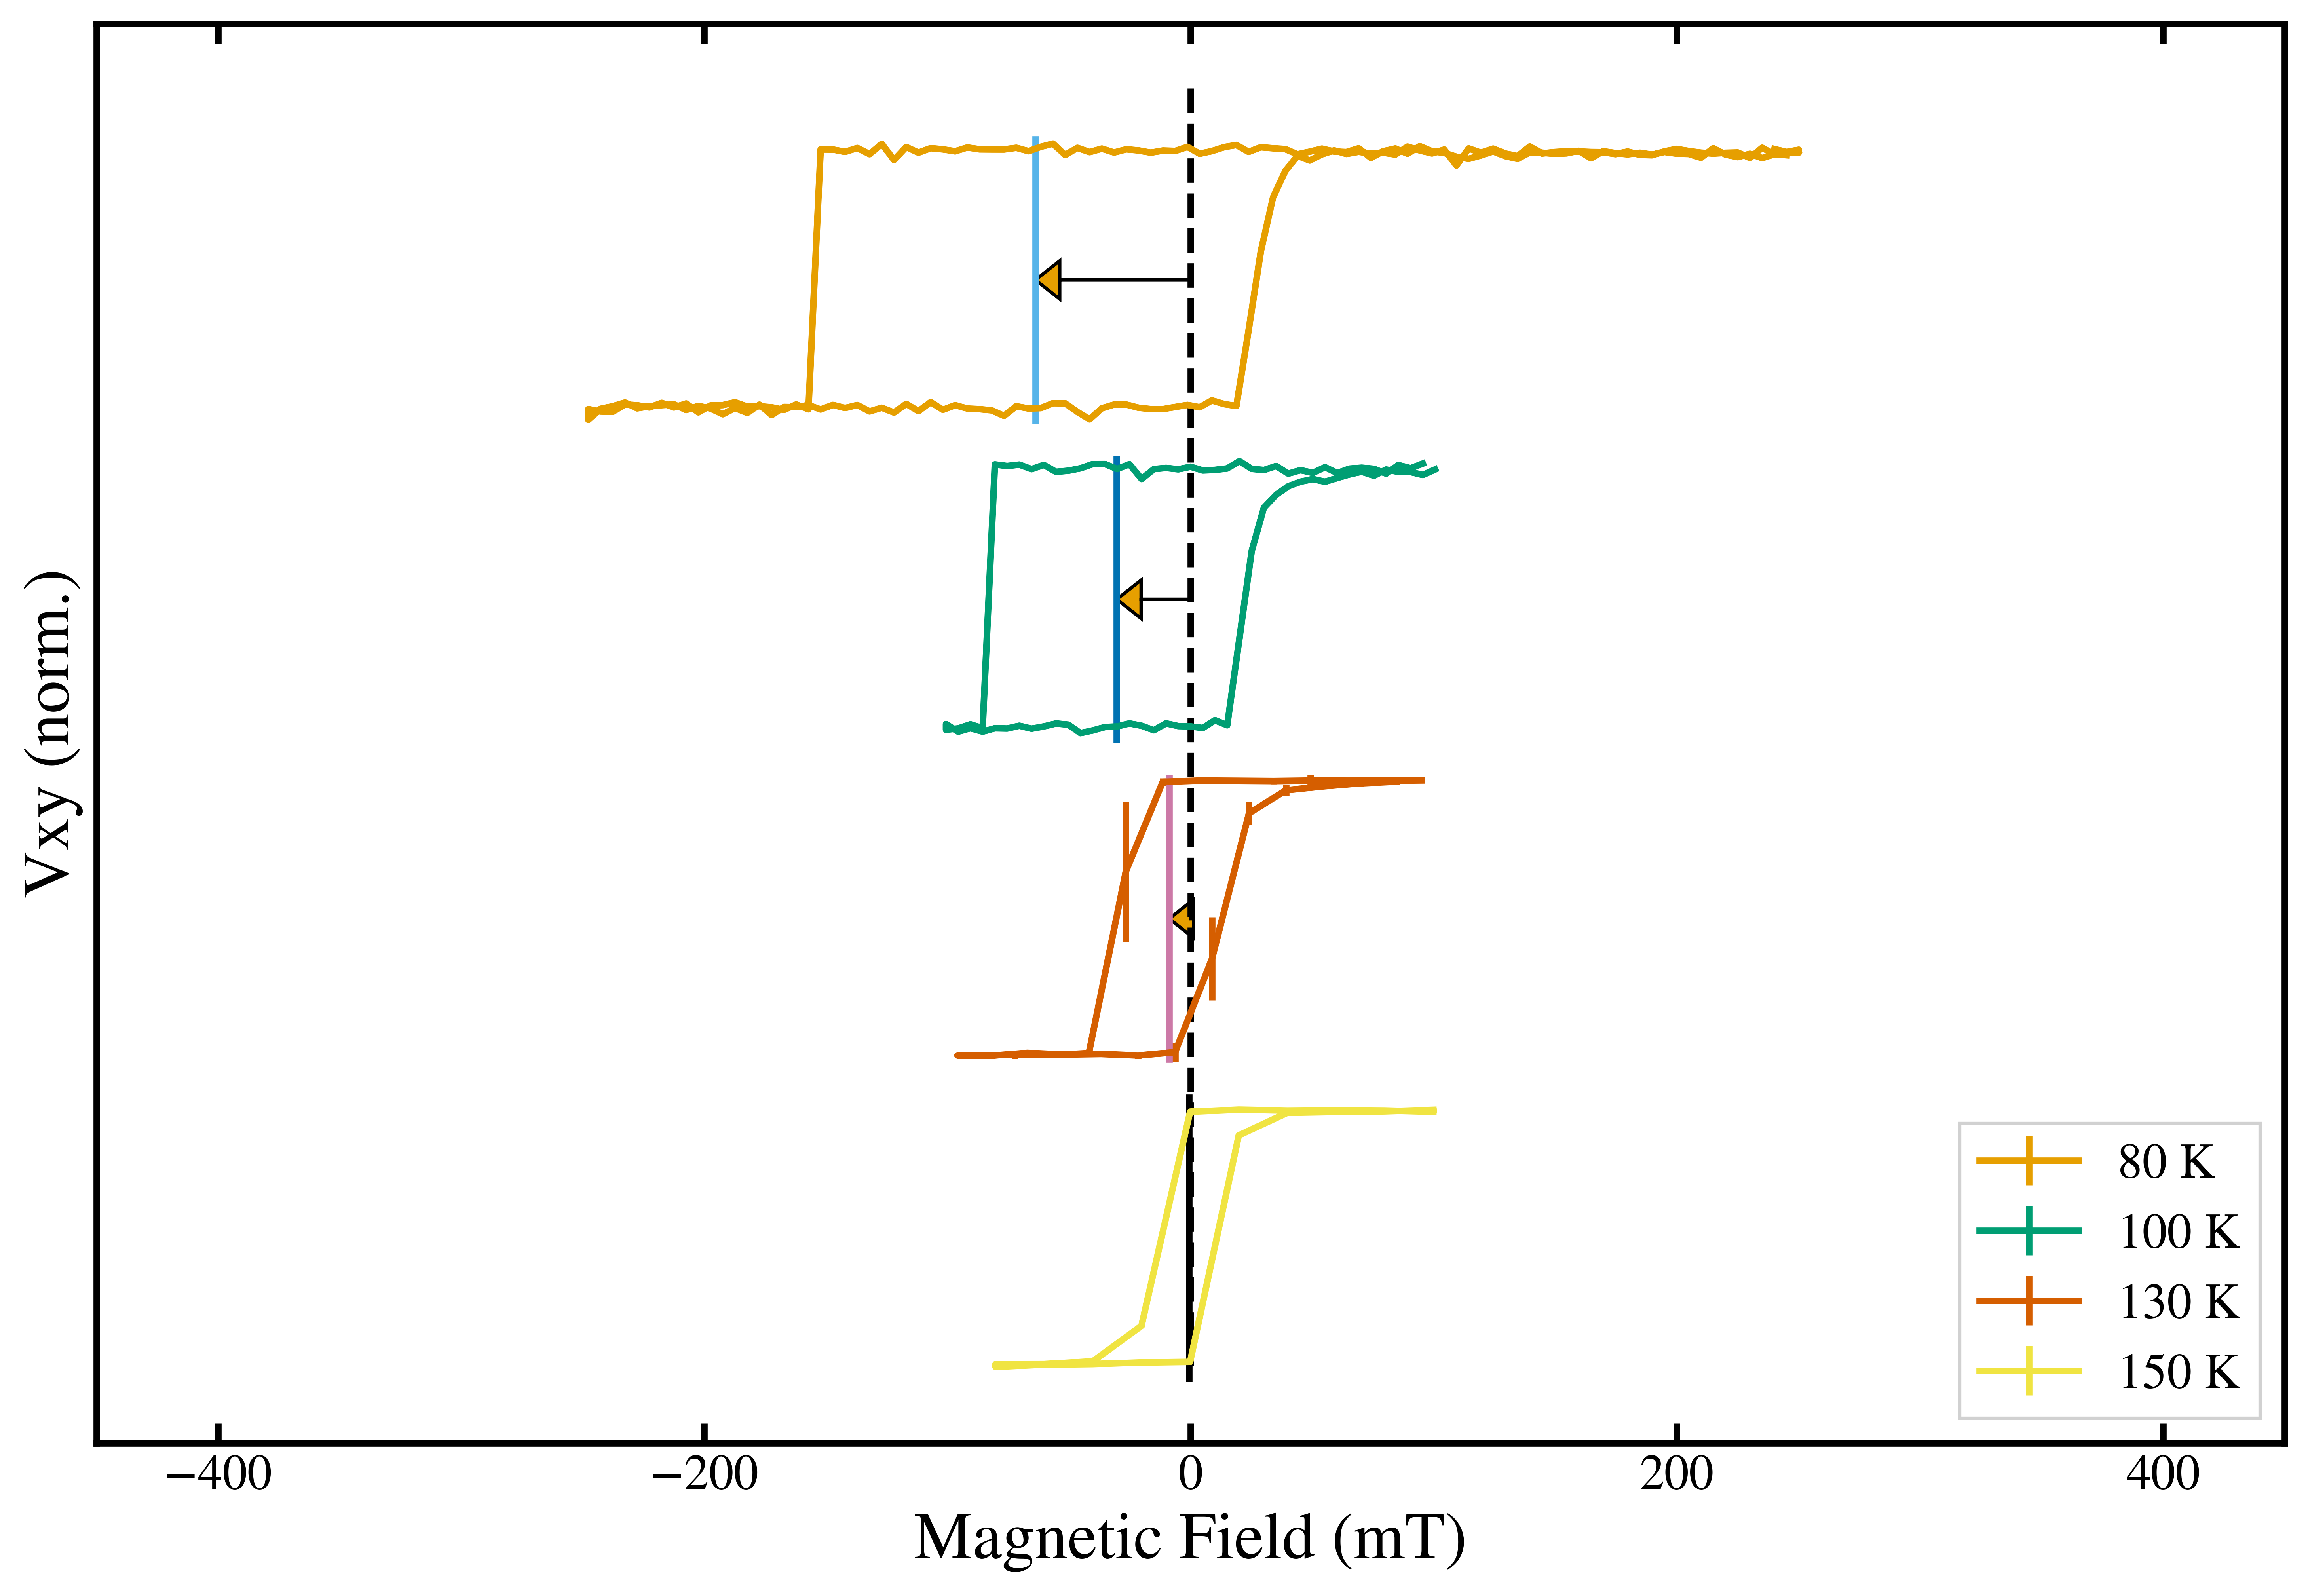

In [15]:
# ── F7: Waterfall 80–150 K ────────────────────────────────────────────────────
# 150 K data clipped to |B| < 100 mT; arrow at 150 K is commented out
temps7   = [80, 100, 130, 150]
offsets7 = [20.5, 18, 15.5, 13]

plt.figure(dpi=600)
for T_val, off in zip(temps7, offsets7):
    i = index_of(T_val)
    if i is None:
        print(f'[WARNING] T={T_val} K not found')
        continue
    F_plot = Field_g[i]; S_plot = Vxy_norm_g[i]; E_plot = Vxy_err_g[i]
    if T_val == 150:
        mask = np.abs(F_plot) < 100
        F_plot, S_plot, E_plot = F_plot[mask], S_plot[mask], E_plot[mask]
    plt.errorbar(F_plot, S_plot + off, E_plot, fmt='-', markersize=1, label=f'{T_val} K')
    plt.plot([HEB_g[i], HEB_g[i]], [off + 1.1, off + 1.1 - 2.2], '-')
    if T_val != 150:   # arrow at 150 K commented out in original
        plt.arrow(0, off, HEB_g[i], 0, head_width=0.3, head_length=10, length_includes_head=True)

plt.legend( loc='lower right', fontsize=15)
plt.plot([0, 0], [22, 12], '--', color='k')
plt.xlabel('Magnetic Field (mT)', fontsize=20)
plt.ylabel('Vxy (norm.)', fontsize=20)
plt.xticks([-400, -200, 0, 200, 400], fontsize=15)
plt.yticks([])
plt.xlim(-450, 450)
plt.tight_layout()
plt.show()